# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

Requirement already up-to-date: plotly in /usr/local/lib/python3.6/dist-packages (4.12.0)


### Import Statements

In [102]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
import iso3166
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [13]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [14]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [15]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [16]:
df_data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [17]:
df_data.shape

(4324, 7)

In [18]:
df_data.columns

Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status'],
      dtype='str')

In [19]:
df_data.isna().sum()

Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [20]:
df_data.duplicated().sum()

np.int64(1)

In [21]:
df_data.duplicated().values.any()

np.True_

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [22]:
df_data.dropna(inplace=True)
df_data.shape

(964, 7)

## Descriptive Statistics

In [23]:
df_data.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,964,964,964,964,964,964,964
unique,25,56,963,962,2,56,4
top,CASC,"LC-39A, Kennedy Space Center, Florida, USA","Wed Nov 05, 2008 00:15 UTC",H-IIA 202 | IGS-Radar 5,StatusActive,450.0,Success
freq,158,120,2,2,586,136,910


In [24]:
df_data.info()

<class 'pandas.DataFrame'>
Index: 964 entries, 0 to 4020
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Organisation    964 non-null    str  
 1   Location        964 non-null    str  
 2   Date            964 non-null    str  
 3   Detail          964 non-null    str  
 4   Rocket_Status   964 non-null    str  
 5   Price           964 non-null    str  
 6   Mission_Status  964 non-null    str  
dtypes: str(7)
memory usage: 60.2 KB


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [36]:
df_data['Organisation'].unique()

<StringArray>
[         'SpaceX',            'CASC',       'Roscosmos',             'ULA',
            'JAXA',        'Northrop',          'ExPace',      'Rocket Lab',
    'Virgin Orbit',             'MHI',     'Arianespace',          'VKS RF',
            'ISRO',             'ILS',        'Eurockot',          'Sandia',
       'Kosmotras',             'ESA',            'NASA',          'Boeing',
        'Lockheed',             'EER', 'Martin Marietta',       'RVSN USSR',
    'US Air Force']
Length: 25, dtype: str

In [32]:
launches_per_company = df_data.groupby('Organisation')["Location"].count().sort_values(ascending=False)
launches_per_company

Organisation
CASC               158
NASA               149
SpaceX              99
ULA                 98
Arianespace         96
Northrop            83
ISRO                67
MHI                 37
VKS RF              33
US Air Force        26
Roscosmos           23
Kosmotras           22
Rocket Lab          13
ILS                 13
Eurockot            13
Martin Marietta      9
Lockheed             8
Boeing               7
JAXA                 3
RVSN USSR            2
EER                  1
ExPace               1
ESA                  1
Sandia               1
Virgin Orbit         1
Name: Location, dtype: int64

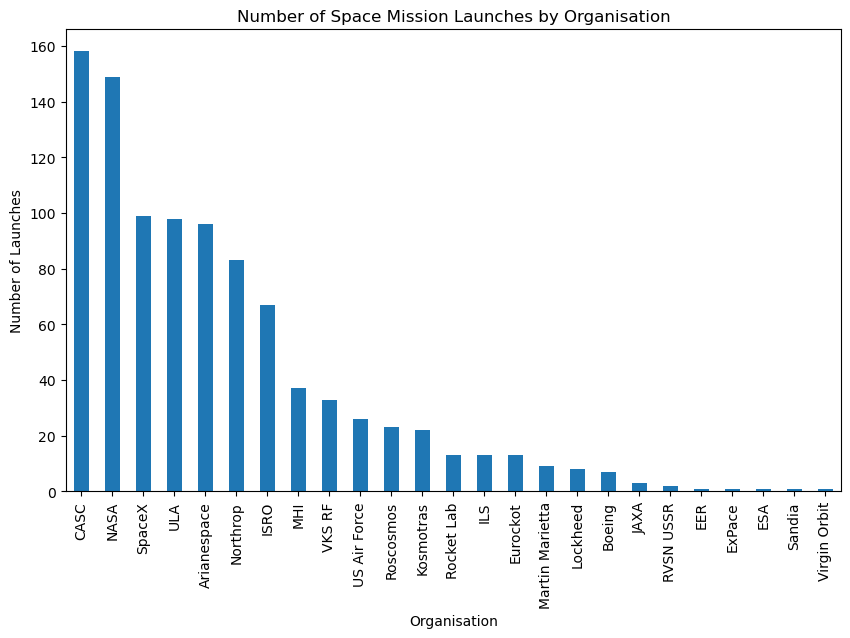

In [34]:
launches_per_company.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Space Mission Launches by Organisation')
plt.xlabel('Organisation')
plt.ylabel('Number of Launches')
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [39]:
df_data["Rocket_Status"].unique()

<StringArray>
['StatusActive', 'StatusRetired']
Length: 2, dtype: str

In [40]:
df_data["Rocket_Status"].value_counts()

Rocket_Status
StatusActive     586
StatusRetired    378
Name: count, dtype: int64

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [42]:
df_data["Mission_Status"].unique()

<StringArray>
['Success', 'Failure', 'Partial Failure', 'Prelaunch Failure']
Length: 4, dtype: str

In [43]:
df_data["Mission_Status"].value_counts()

Mission_Status
Success              910
Failure               36
Partial Failure       17
Prelaunch Failure      1
Name: count, dtype: int64

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [52]:
df_data["Price"] = df_data["Price"].str.replace(",", "")
df_data["Price"] = df_data["Price"].astype(float)
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


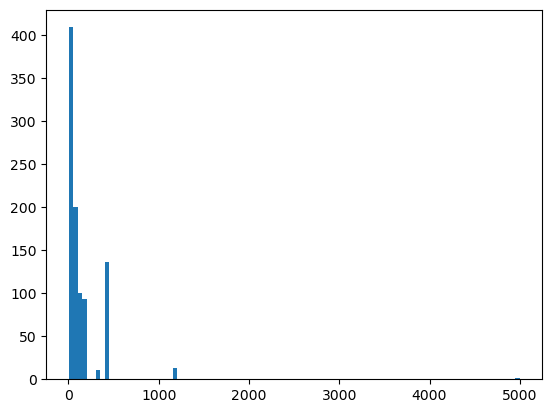

In [59]:
plt.hist(df_data["Price"], bins=100)
plt.show()

In [61]:
fig = px.histogram(df_data, x="Price")
fig.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [115]:
df_data_all = pd.read_csv('mission_launches.csv')
df_data_all.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [116]:
df_data_all["Country"] = df_data_all["Location"].apply(lambda x: x.split(",")[-1])
df_data_all["Country"] = df_data_all["Country"].str.strip()
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA


In [117]:
df_data_all["Country"].unique()

<StringArray>
[                           'USA',                          'China',
                     'Kazakhstan',                          'Japan',
                         'Israel',                    'New Zealand',
                         'Russia',      'Shahrud Missile Test Site',
                         'France',                           'Iran',
                          'India',                     'New Mexico',
                     'Yellow Sea',                    'North Korea',
 'Pacific Missile Range Facility',                  'Pacific Ocean',
                    'South Korea',                    'Barents Sea',
                         'Brazil',                   'Gran Canaria',
                          'Kenya',                      'Australia']
Length: 22, dtype: str

In [118]:
df_data_all.loc[df_data_all["Country"] == "Russia", "Country"] = "Russian Federation"
df_data_all.loc[df_data_all["Country"] == "New Mexico", "Country"] = "USA"
df_data_all.loc[df_data_all["Country"] == "Yellow Sea", "Country"] = "China"
df_data_all.loc[df_data_all["Country"] == "Shahrud Missile Test Site", "Country"] = "Iran, Islamic Republic of"
df_data_all.loc[df_data_all["Country"] == "Iran", "Country"] = "Iran, Islamic Republic of"
df_data_all.loc[df_data_all["Country"] == "Pacific Missile Range Facility", "Country"] = "USA"
df_data_all.loc[df_data_all["Country"] == "Pacific Ocean", "Country"] = "USA"
df_data_all.loc[df_data_all["Country"] == "Barents Sea", "Country"] = "Russian Federation"
df_data_all.loc[df_data_all["Country"] == "Gran Canaria", "Country"] = "USA"
df_data_all.loc[df_data_all["Country"] == "North Korea", "Country"] = "Korea, Democratic People's Republic of"
df_data_all.loc[df_data_all["Country"] == "South Korea", "Country"] = "Korea, Republic of"
df_data_all["Country"].unique()

<StringArray>
[                                   'USA',
                                  'China',
                             'Kazakhstan',
                                  'Japan',
                                 'Israel',
                            'New Zealand',
                     'Russian Federation',
              'Iran, Islamic Republic of',
                                 'France',
                                  'India',
 'Korea, Democratic People's Republic of',
                     'Korea, Republic of',
                                 'Brazil',
                                  'Kenya',
                              'Australia']
Length: 15, dtype: str

In [119]:
df_data_all["Alpha3"] = df_data_all["Country"].apply(lambda x: countries.get(x).alpha3)

In [124]:
df_data_all["Mission_Status"].unique()

<StringArray>
['Success', 'Failure', 'Prelaunch Failure', 'Partial Failure']
Length: 4, dtype: str

In [130]:
df_data_all["Mission_Failure"] = (df_data_all["Mission_Status"] == "Failure") | (df_data_all["Mission_Status"] == "Partial Failure")
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False


In [132]:
df_failures = df_data_all.groupby(["Country", "Alpha3"], as_index=False)["Mission_Failure"].sum()
df_failures

,Country,Alpha3,Mission_Failure
0,Australia,AUS,3
1,Brazil,BRA,2
2,China,CHN,25
3,France,FRA,18
4,India,IND,13
5,"Iran, Islamic Republic of",IRN,8
6,Israel,ISR,2
7,Japan,JPN,13
8,Kazakhstan,KAZ,92
9,Kenya,KEN,0


# Use a Choropleth Map to Show the Number of Failures by Country


In [134]:
fig = px.choropleth(df_failures, locations="Alpha3",
                    color="Mission_Failure", # lifeExp is a column of gapminder
                    hover_name="Country", # column to add to hover information
                    color_continuous_scale=px.colors.sequential.matter)
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [135]:
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False


In [136]:
fig = px.sunburst(df_data_all, path=['Country', 'Organisation', 'Mission_Status'])
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [138]:
df_money_spent = df_data.groupby(["Organisation"], as_index=False)["Price"].sum()
df_money_spent.sort_values(by="Price", ascending=False, inplace=True)
df_money_spent

,Organisation,Price
14,NASA,"76,280.00"
0,Arianespace,"16,345.00"
21,ULA,"14,798.00"
16,RVSN USSR,"10,000.00"
2,CASC,"6,340.26"
20,SpaceX,"5,444.00"
15,Northrop,"3,930.00"
12,MHI,"3,532.50"
8,ISRO,"2,177.00"
22,US Air Force,"1,550.92"


# Analyse the Amount of Money Spent by Organisation per Launch

In [143]:
df_money_spent = df_data.groupby(["Organisation"], as_index=False).agg({"Price": "sum", "Detail": "count"})
df_money_spent.rename(columns={'Detail': 'Launches'}, inplace=True)
df_money_spent["Price_per_Launch"] = df_money_spent["Price"] / df_money_spent["Launches"]
df_money_spent.sort_values(by="Price_per_Launch", ascending=False, inplace=True)
df_money_spent

,Organisation,Price,Launches,Price_per_Launch
16,RVSN USSR,"10,000.00",2,"5,000.00"
14,NASA,"76,280.00",149,511.95
1,Boeing,"1,241.00",7,177.29
0,Arianespace,"16,345.00",96,170.26
21,ULA,"14,798.00",98,151.00
7,ILS,"1,320.00",13,101.54
12,MHI,"3,532.50",37,95.47
13,Martin Marietta,721.40,9,80.16
22,US Air Force,"1,550.92",26,59.65
9,JAXA,168.00,3,56.00


# Chart the Number of Launches per Year

In [154]:
df_data["Year"] = df_data["Date"].apply(lambda x: x.split(",")[1].strip().split(" ")[0])
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Year
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,USA,2020
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,2020
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Kazakhstan,2020
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,2020
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success,China,2020


In [166]:
launches_per_year = df_data.groupby(["Year"], as_index=False)["Detail"].count()
launches_per_year.rename(columns={'Detail': 'Launches'}, inplace=True)
launches_per_year["Year"] = pd.to_numeric(launches_per_year["Year"])
launches_per_year

,Year,Launches
0,1964,2
1,1965,2
2,1966,3
3,1967,8
4,1968,10
5,1969,8
6,1970,1
7,1971,2
8,1972,2
9,1973,1


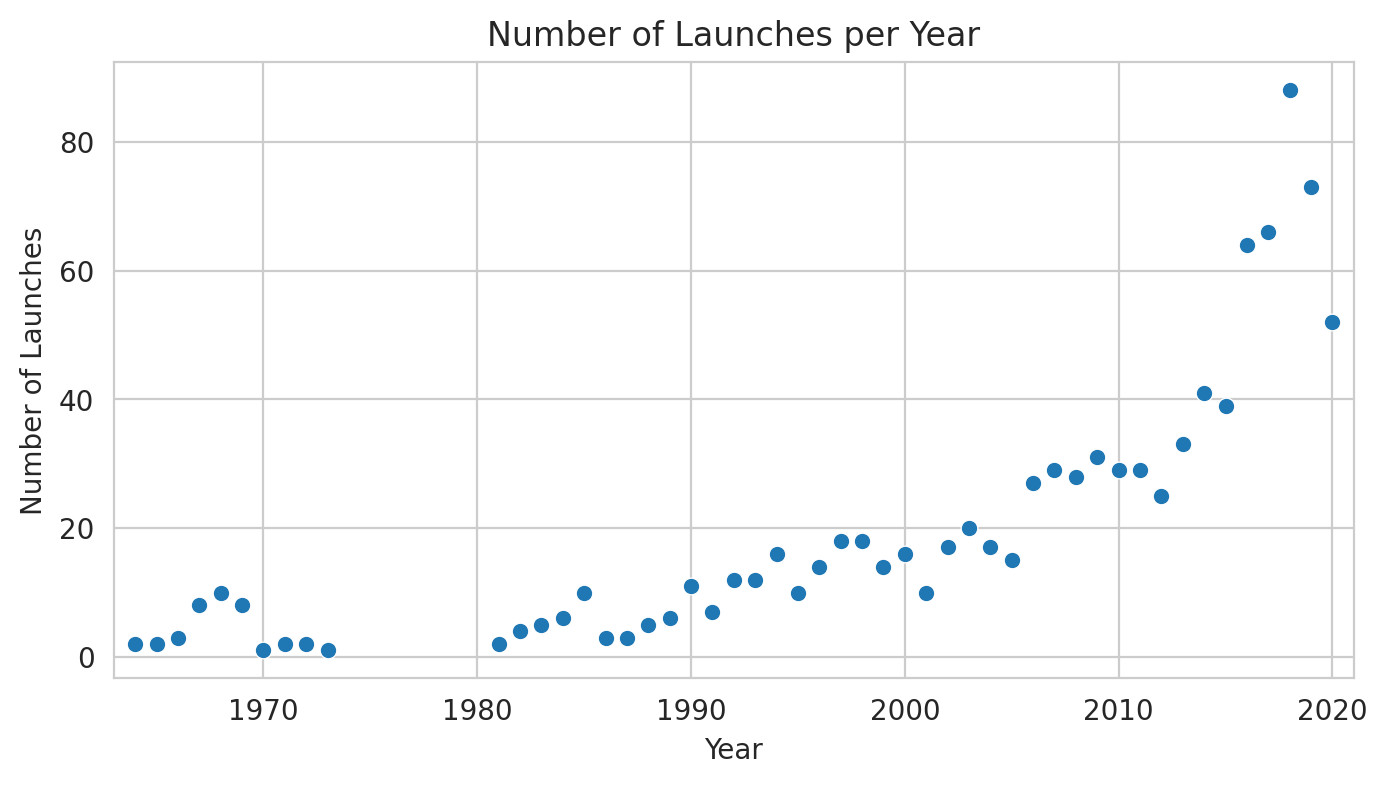

In [170]:
plt.figure(figsize=(8, 4), dpi=200)
with sns.axes_style("whitegrid"):
    ax = sns.scatterplot(data=launches_per_year, x="Year", y="Launches")
#     plt.xticks(rotation=90)
    ax.set(title="Number of Launches per Year",
            ylabel='Number of Launches',
            xlabel='Year')
    
    ax.set_xlim(1963, 2021)

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [173]:
df_data["Month"] = df_data["Date"].apply(lambda x: x.split(" ")[1].strip())
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Year,Month
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,USA,2020,Aug
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,2020,Aug
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Kazakhstan,2020,Jul
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,2020,Jul
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success,China,2020,Jul


In [177]:
launches_per_month = df_data.groupby(["Month"], as_index=False)["Detail"].count()
launches_per_month.rename(columns={'Detail': 'Launches'}, inplace=True)
key = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
launches_per_month["Month"] = pd.Categorical(launches_per_month["Month"], categories=key, ordered=True)
launches_per_month.sort_values(by="Month", inplace=True)
launches_per_month

,Month,Launches
4,Jan,66
3,Feb,60
7,Mar,77
0,Apr,91
8,May,86
6,Jun,85
5,Jul,77
1,Aug,82
11,Sep,88
10,Oct,83


In [178]:
launches_per_month.dtypes

Month       category
Launches       int64
dtype: object

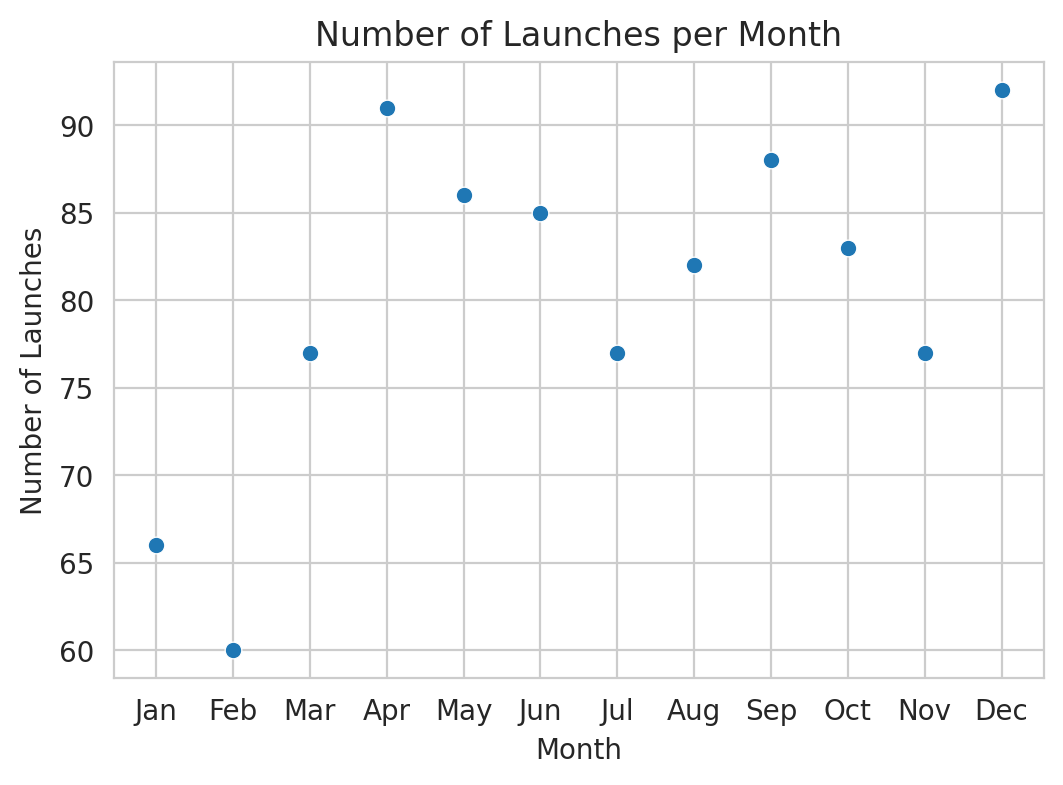

In [180]:
plt.figure(figsize=(6, 4), dpi=200)
with sns.axes_style("whitegrid"):
    ax = sns.scatterplot(data=launches_per_month, x="Month", y="Launches")
#     plt.xticks(rotation=90)
    ax.set(title="Number of Launches per Month",
            ylabel='Number of Launches',
            xlabel='Month')
    
    # ax.set_xlim(1963, 2021)

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [181]:
price_over_year = df_data.groupby(["Year"], as_index=False)["Price"].mean()
price_over_year.rename(columns={'Price': 'Average Price'}, inplace=True)
price_over_year["Year"] = pd.to_numeric(price_over_year["Year"])
price_over_year

,Year,Average Price
0,1964,63.23
1,1965,63.23
2,1966,59.00
3,1967,196.62
4,1968,279.20
5,1969,609.50
6,1970,"1,160.00"
7,1971,"1,160.00"
8,1972,"1,160.00"
9,1973,"1,160.00"


In [182]:
chart = px.line(price_over_year,
                x="Year",
                y="Average Price")

chart.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [187]:
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False


In [188]:
df_data_all["Organisation"].unique()

<StringArray>
[          'SpaceX',             'CASC',        'Roscosmos',
              'ULA',             'JAXA',         'Northrop',
           'ExPace',              'IAI',       'Rocket Lab',
     'Virgin Orbit',           'VKS RF',              'MHI',
             'IRGC',      'Arianespace',              'ISA',
      'Blue Origin',             'ISRO',             'Exos',
              'ILS',          'i-Space',         'OneSpace',
        'Landspace',         'Eurockot',      'Land Launch',
            'CASIC',             'KCST',           'Sandia',
        'Kosmotras',       'Khrunichev',       'Sea Launch',
             'KARI',              'ESA',             'NASA',
           'Boeing',             'ISAS',              'SRC',
             'MITT',         'Lockheed',              'AEB',
          'Starsem',        'RVSN USSR',              'EER',
 'General Dynamics',  'Martin Marietta',         'Yuzhmash',
          'Douglas',              'ASI',     'US Air Force',
          

In [189]:
df_data_all["Year"] = df_data_all["Date"].apply(lambda x: x.split(",")[1].strip().split(" ")[0])
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure,Year
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False,2020
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False,2020
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False,2020
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False,2020
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False,2020


In [190]:
top_10_organisations = df_data_all.groupby(["Organisation"], as_index=False)["Detail"].count()
top_10_organisations.sort_values(by="Detail", ascending=False, inplace=True)
top_10_organisations = top_10_organisations.head(10)
top_10_organisations

,Organisation,Detail
40,RVSN USSR,1777
3,Arianespace,279
17,General Dynamics,251
7,CASC,251
35,NASA,203
52,VKS RF,201
49,US Air Force,161
48,ULA,140
6,Boeing,136
34,Martin Marietta,114


In [195]:
organisations_names = top_10_organisations["Organisation"].unique()

In [214]:
df_top_10_organisations = df_data_all[df_data_all["Organisation"].isin(organisations_names)]
df_top_10_organisations = df_top_10_organisations.groupby(["Year", "Organisation"], as_index=False)["Detail"].count()
df_top_10_organisations.rename(columns={'Detail': 'Launches'}, inplace=True)
df_top_10_organisations["Year"] = pd.to_numeric(df_top_10_organisations["Year"])
df_top_10_organisations.sort_values(by="Year", inplace=True)
df_top_10_organisations.head()

,Year,Organisation,Launches
0,1957,RVSN USSR,2
1,1958,NASA,2
2,1958,RVSN USSR,5
3,1958,US Air Force,2
4,1959,General Dynamics,1


In [215]:
chart = px.line(df_top_10_organisations,
                x="Year",
                y="Launches",
                color="Organisation")

chart.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [251]:
df_USA_USSR = df_data_all[df_data_all["Country"].isin(["USA", "Russian Federation", "Kazakhstan"])]
df_USA_USSR = df_USA_USSR.groupby(["Country", "Year"], as_index=False)["Detail"].count()
df_USA_USSR.rename(columns={'Detail': 'Launches'}, inplace=True)
df_USA_USSR["Country"] = df_USA_USSR["Country"].str.replace("Russian Federation", "Russia")
df_USA_USSR["Year"] = pd.to_numeric(df_USA_USSR["Year"])
df_USA_USSR.sort_values(by="Year", inplace=True)
df_USA_USSR.head()

,Country,Year,Launches
0,Kazakhstan,1957,2
123,USA,1957,1
124,USA,1958,23
1,Kazakhstan,1958,5
2,Kazakhstan,1959,4


In [253]:
df = df_USA_USSR.copy()

# Step 1: Create a mask for USSR period
mask = (df["Year"] <= 1991) & (df["Country"].isin(["Russia", "Kazakhstan"]))

# Step 2: Replace country name with USSR for that period
df.loc[mask, "Country"] = "USSR"

# Step 3: Group and sum launches
df_USA_USSR = (df.groupby(["Country", "Year"], as_index=False)["Launches"].sum())
df_USA_USSR.sort_values(by="Year", inplace=True)
df_USA_USSR.head()

,Country,Year,Launches
57,USA,1957,1
121,USSR,1957,2
122,USSR,1958,5
58,USA,1958,23
59,USA,1959,16


In [254]:
df_USA_USSR.dtypes

Country       str
Year        int64
Launches    int64
dtype: object

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [256]:
fig = px.pie(df_USA_USSR, values='Launches', names='Country', title='Total Number of Launches by Country')
fig.show()

In [257]:
df_USA_USSR_before_1991 = df_USA_USSR[df_USA_USSR["Year"] <= 1991]
fig = px.pie(df_USA_USSR_before_1991, values='Launches', names='Country', title='Total Number of Launches by Country')
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [258]:
chart = px.line(df_USA_USSR,
                x="Year",
                y="Launches",
                color="Country")

chart.show()

## Chart the Total Number of Mission Failures Year on Year.

In [259]:
df_data_all.head()


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure,Year
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False,2020
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False,2020
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False,2020
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False,2020
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False,2020


In [260]:
mission_failures = df_data_all.groupby(["Year"], as_index=False)["Mission_Failure"].sum()
mission_failures

,Year,Mission_Failure
0,1957,1
1,1958,22
2,1959,12
3,1960,20
4,1961,20
...,...,...
59,2016,3
60,2017,8
61,2018,4
62,2019,8


In [261]:
chart = px.line(mission_failures,
                x="Year",
                y="Mission_Failure")

chart.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [262]:
mission_failures_percentage = df_data_all.groupby(["Year"], as_index=False).agg({"Mission_Failure": "sum", "Detail": "count"})
mission_failures_percentage["Mission_Failure_Percentage"] = mission_failures_percentage["Mission_Failure"] / mission_failures_percentage["Detail"] * 100

In [263]:
chart = px.line(mission_failures_percentage,
                x="Year",
                y="Mission_Failure_Percentage")

chart.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [280]:
df_data_all["Year"] = pd.to_numeric(df_data_all["Year"])

df = df_data_all.copy()

# Step 1: Create a mask for USSR period
mask = (df["Year"] <= 1991) & (df["Country"].isin(["Russian Federation", "Kazakhstan"]))

# Step 2: Replace country name with USSR for that period
df.loc[mask, "Country"] = "USSR"

# Step 3: Group and sum launches
leader_df = (df.groupby(["Country", "Year"], as_index=False)["Detail"].count())
leader_df.sort_values(by="Year", inplace=True)

leader_df.rename(columns={'Detail': 'Launches'}, inplace=True)

leader_df = leader_df.loc[leader_df.groupby("Year")["Launches"].idxmax()].reset_index(drop=True)
leader_df

,Country,Year,Launches
0,USSR,1957,2
1,USA,1958,23
2,USA,1959,16
3,USA,1960,30
4,USA,1961,43
...,...,...,...
59,USA,2016,27
60,USA,2017,30
61,China,2018,39
62,China,2019,34


In [281]:
chart = px.scatter(leader_df,
                x="Year",
                y="Launches",
                color="Country")

chart.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [282]:
df_data_all.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Alpha3,Mission_Failure,Year
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,USA,False,2020
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,False,2020
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA,False,2020
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,KAZ,False,2020
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,USA,False,2020


In [283]:
organisation_df = (df_data_all.groupby(["Organisation", "Year"], as_index=False)["Detail"].count())
organisation_df.sort_values(by="Year", inplace=True)
organisation_df.rename(columns={'Detail': 'Launches'}, inplace=True)
organisation_df.head()

,Organisation,Year,Launches
623,US Navy,1957,1
497,RVSN USSR,1957,2
598,US Air Force,1958,2
624,US Navy,1958,12
498,RVSN USSR,1958,5


In [284]:
organisation_df = organisation_df.loc[organisation_df.groupby("Year")["Launches"].idxmax()].reset_index(drop=True)
organisation_df.head()

,Organisation,Year,Launches
0,RVSN USSR,1957,2
1,US Navy,1958,12
2,US Air Force,1959,10
3,US Air Force,1960,21
4,US Air Force,1961,23


In [285]:
chart = px.scatter(organisation_df,
                x="Year",
                y="Launches",
                color="Organisation")

chart.show()